# Etapa 1: Preprocesamiento y EDA

In [1]:
# Librerías
# ----------------------------

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [57]:
# Carga de dataset
# ----------------------------

df = pd.read_excel("Online Retail.xlsx")

print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
# Conversion a CSV
# ----------------------------

df = pd.read_csv(
    "OnlineRetail.csv",
    parse_dates=["InvoiceDate"]
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
# Limpieza
# ----------------------------

# Eliminar registros sin cliente identificado
df = df[df["CustomerID"].notna()] 

# Eliminar facturas canceladas (InvoiceNo comienza con "C")
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Eliminar cantidades no positivas
df = df[df["Quantity"] > 0]

# Eliminar precios nulos o negativos
df = df[df["UnitPrice"] > 0]

# Conservar únicamente compras de Reino Unido
df = df[df["Country"] == "United Kingdom"]

# Calcular el monto total por transacción
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]


In [4]:
# Agregación a nivel cliente (RFM)
# ----------------------------

# Fecha de referencia (un día después de la última compra)
fecha_ref = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Construcción de variables RFM
rfm = (
    df.groupby("CustomerID")
      .agg({
          "InvoiceDate": lambda x: (fecha_ref - x.max()).days,  # Recencia
          "InvoiceNo": "nunique",                               # Frecuencia
          "TotalPrice": "sum"                                   # Monto
      })
      .rename(columns={
          "InvoiceDate": "recencia",
          "InvoiceNo": "frecuencia",
          "TotalPrice": "monto"
      })
      .reset_index()
)

# Ver las primeras filas
rfm.head()

,CustomerID,recencia,frecuencia,monto
0,12346.0,326,1,77183.60
1,12747.0,2,11,4196.01
2,12748.0,1,209,33719.73
3,12749.0,4,5,4090.88
4,12820.0,3,4,942.34


In [5]:
rfm.describe()

,CustomerID,recencia,frecuencia,monto
count,3920.000000,3920.000000,3920.000000,3920.000000
mean,15562.059694,92.208418,4.246429,1864.385601
std,1576.594671,99.533854,7.199202,7482.817477
min,12346.000000,1.000000,1.000000,3.750000
25%,14208.750000,18.000000,1.000000,300.280000
50%,15569.500000,51.000000,2.000000,652.280000
75%,16913.250000,143.000000,5.000000,1576.585000
max,18287.000000,374.000000,209.000000,259657.300000


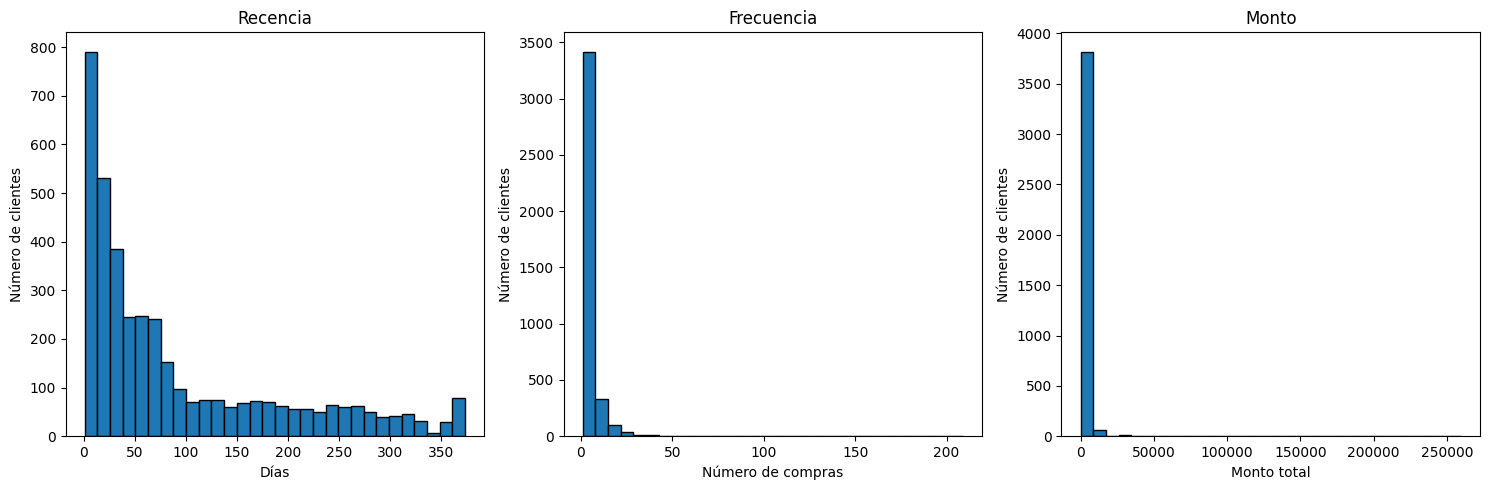

In [6]:
# Histogramas
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recencia
axes[0].hist(rfm["recencia"], bins=30, edgecolor="black")
axes[0].set_title("Recencia")
axes[0].set_xlabel("Días")
axes[0].set_ylabel("Número de clientes")

# Frecuencia
axes[1].hist(rfm["frecuencia"], bins=30, edgecolor="black")
axes[1].set_title("Frecuencia")
axes[1].set_xlabel("Número de compras")
axes[1].set_ylabel("Número de clientes")

# Monto
axes[2].hist(rfm["monto"], bins=30, edgecolor="black")
axes[2].set_title("Monto")
axes[2].set_xlabel("Monto total")
axes[2].set_ylabel("Número de clientes")

plt.tight_layout()
plt.show()

Los histogramas muestran que las tres variables presentan distribuciones asimétricas hacia la derecha. La mayoría de los clientes realizan pocas compras y generan montos bajos, mientras que un pequeño grupo concentra valores muy elevados de frecuencia y gasto. En el caso de la recencia, predominan los clientes con compras recientes, aunque existe una cola larga de clientes que no han comprado durante un periodo considerable.

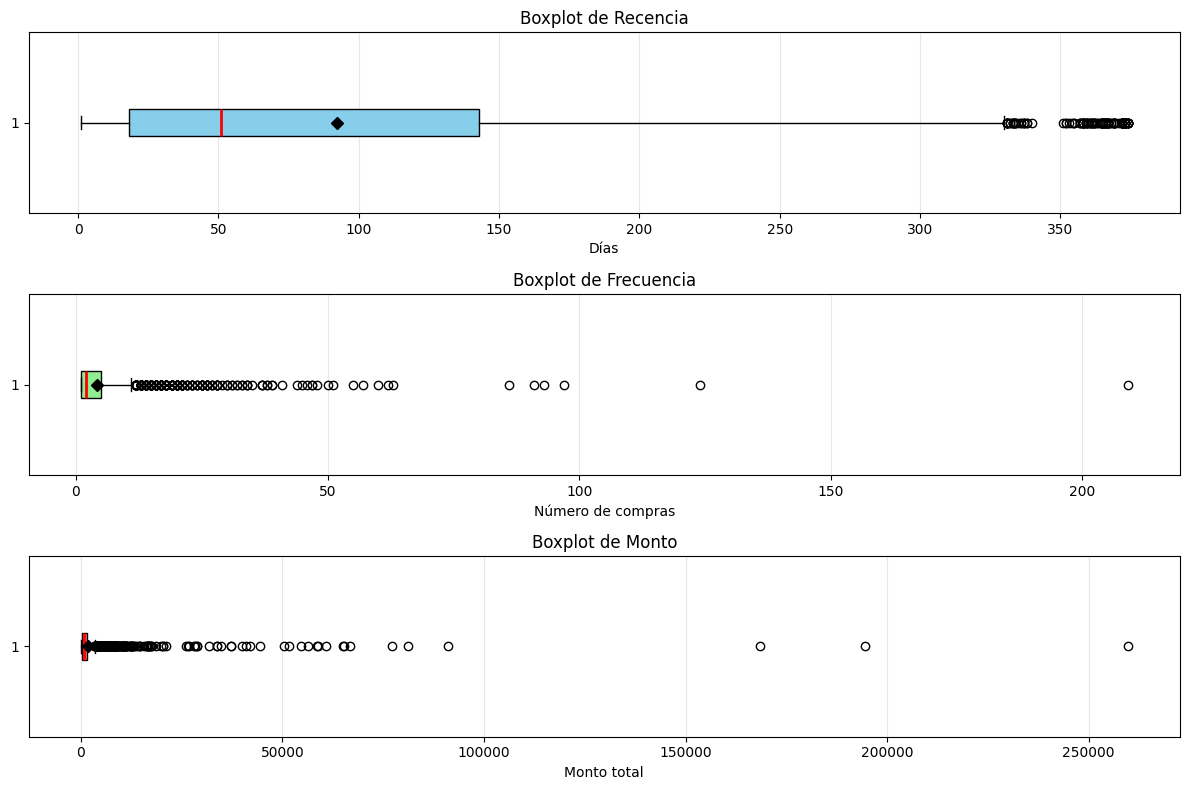

In [7]:
# Boxplots
# ----------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Recencia
axes[0].boxplot(
    rfm["recencia"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[0].set_title("Boxplot de Recencia")
axes[0].set_xlabel("Días")
axes[0].grid(axis="x", alpha=0.3)

# Frecuencia
axes[1].boxplot(
    rfm["frecuencia"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[1].set_title("Boxplot de Frecuencia")
axes[1].set_xlabel("Número de compras")
axes[1].grid(axis="x", alpha=0.3)

# Monto
axes[2].boxplot(
    rfm["monto"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="salmon"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[2].set_title("Boxplot de Monto")
axes[2].set_xlabel("Monto total")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Los boxplots confirman la presencia de una gran cantidad de valores atípicos, especialmente en las variables frecuencia y monto, donde algunos clientes realizan muchas más compras o generan un gasto considerablemente superior al resto. En recencia también se observan clientes con tiempos de inactividad mucho mayores que la mayoría.

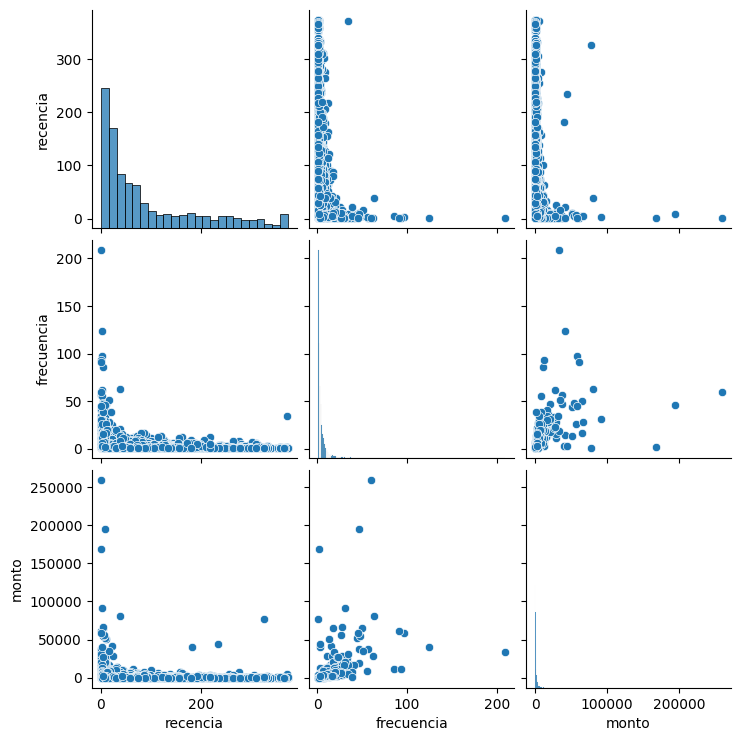

In [8]:
# Pairplot
# ----------------------------

vars = ["recencia", "frecuencia", "monto"]

sns.pairplot(
    rfm,
    vars=vars,
    diag_kind="hist"   # o "kde"
)

plt.show()

El pairplot muestra que las tres variables presentan distribuciones altamente asimétricas y una fuerte concentración de clientes en valores bajos de frecuencia y monto. Además, se observa una relación positiva entre frecuencia y monto, ya que los clientes que compran con mayor frecuencia tienden a generar un mayor gasto total. En contraste, la recencia no presenta una relación lineal clara con las otras variables y se identifican numerosos valores atípicos.

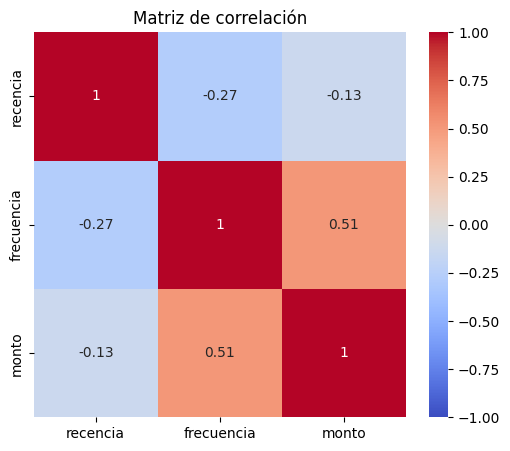

In [9]:
# Matriz de correlación
# ----------------------------

corr = rfm[["recencia", "frecuencia", "monto"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación")
plt.show()

La matriz de correlación muestra una correlación positiva moderada (0.51) entre frecuencia y monto, indicando que los clientes que compran con mayor frecuencia tienden a gastar más. En contraste, la recencia presenta correlaciones negativas débiles con frecuencia (-0.27) y monto (-0.13), lo que sugiere que los clientes que llevan más tiempo sin comprar tienden, en promedio, a realizar menos compras y generar un menor gasto.

In [10]:
# Coeficientes de asimetría
# ----------------------------

recencia_skew = rfm['recencia'].skew()
frecuencia_skew = rfm['frecuencia'].skew()
monto_skew =rfm['monto'].skew()

print(f"El coeficiente de asimetría de la recencia es: {recencia_skew:.2f}")
print(f"El coeficiente de asimetría de la frecuencia es: {frecuencia_skew:.2f}")
print(f"El coeficiente de asimetría del monto es: {monto_skew:.2f}")

El coeficiente de asimetría de la recencia es: 1.25
El coeficiente de asimetría de la frecuencia es: 10.75
El coeficiente de asimetría del monto es: 20.20


Los coeficientes de asimetría confirman que las tres variables presentan asimetría positiva, siendo especialmente pronunciada en frecuencia (10.75) y monto (20.20). Esto indica la presencia de una gran concentración de clientes con valores bajos y una pequeña proporción con valores extremadamente altos. La recencia (1.25) también presenta asimetría positiva, aunque de menor magnitud.

In [11]:
# Transformación logarítmica
# ----------------------------

rfm_log = rfm.copy()
rfm_log["recencia"] = np.log1p(rfm_log["recencia"])
rfm_log["frecuencia"] = np.log1p(rfm_log["frecuencia"])
rfm_log["monto"] = np.log1p(rfm_log["monto"])

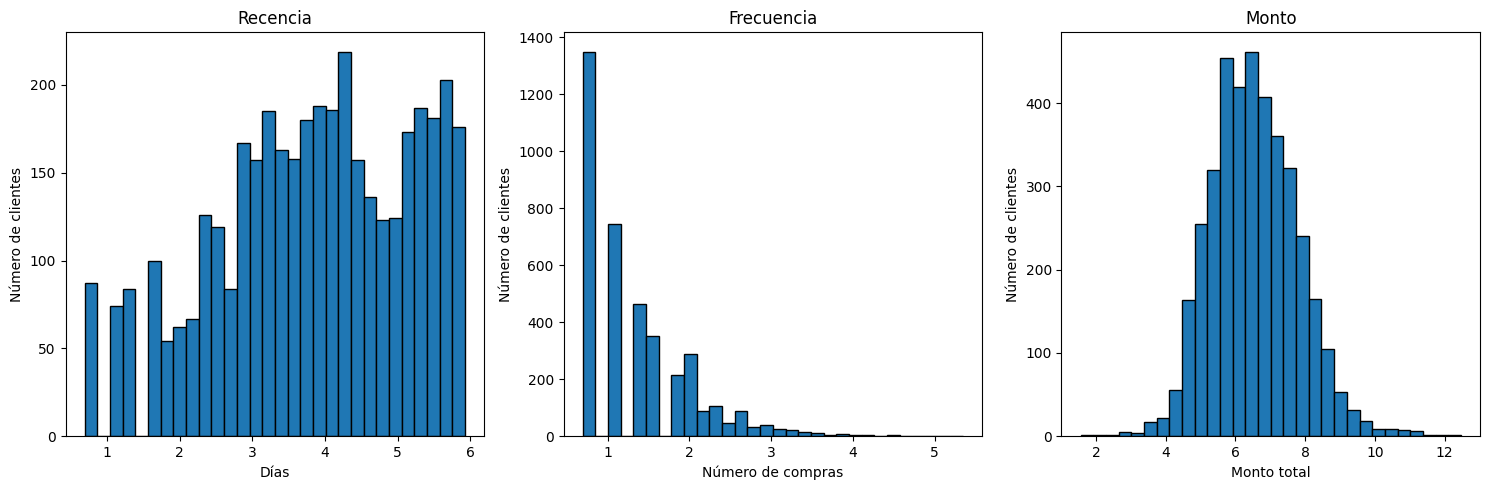

In [12]:
# Histogramas
# ----------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recencia
axes[0].hist(rfm_log["recencia"], bins=30, edgecolor="black")
axes[0].set_title("Recencia")
axes[0].set_xlabel("Días")
axes[0].set_ylabel("Número de clientes")

# Frecuencia
axes[1].hist(rfm_log["frecuencia"], bins=30, edgecolor="black")
axes[1].set_title("Frecuencia")
axes[1].set_xlabel("Número de compras")
axes[1].set_ylabel("Número de clientes")

# Monto
axes[2].hist(rfm_log["monto"], bins=30, edgecolor="black")
axes[2].set_title("Monto")
axes[2].set_xlabel("Monto total")
axes[2].set_ylabel("Número de clientes")

plt.tight_layout()
plt.show()

Después de aplicar la transformación logarítmica (log1p), las distribuciones presentan una asimetría considerablemente menor. La variable monto adquiere una forma cercana a una distribución normal, mientras que frecuencia reduce notablemente su cola derecha, aunque conserva cierta asimetría debido a la gran cantidad de clientes con pocas compras. La recencia también muestra una distribución más equilibrada. En conjunto, la transformación disminuye la influencia de los valores extremos y genera variables más adecuadas para algoritmos basados en distancias, como K-Means y el clustering jerárquico.

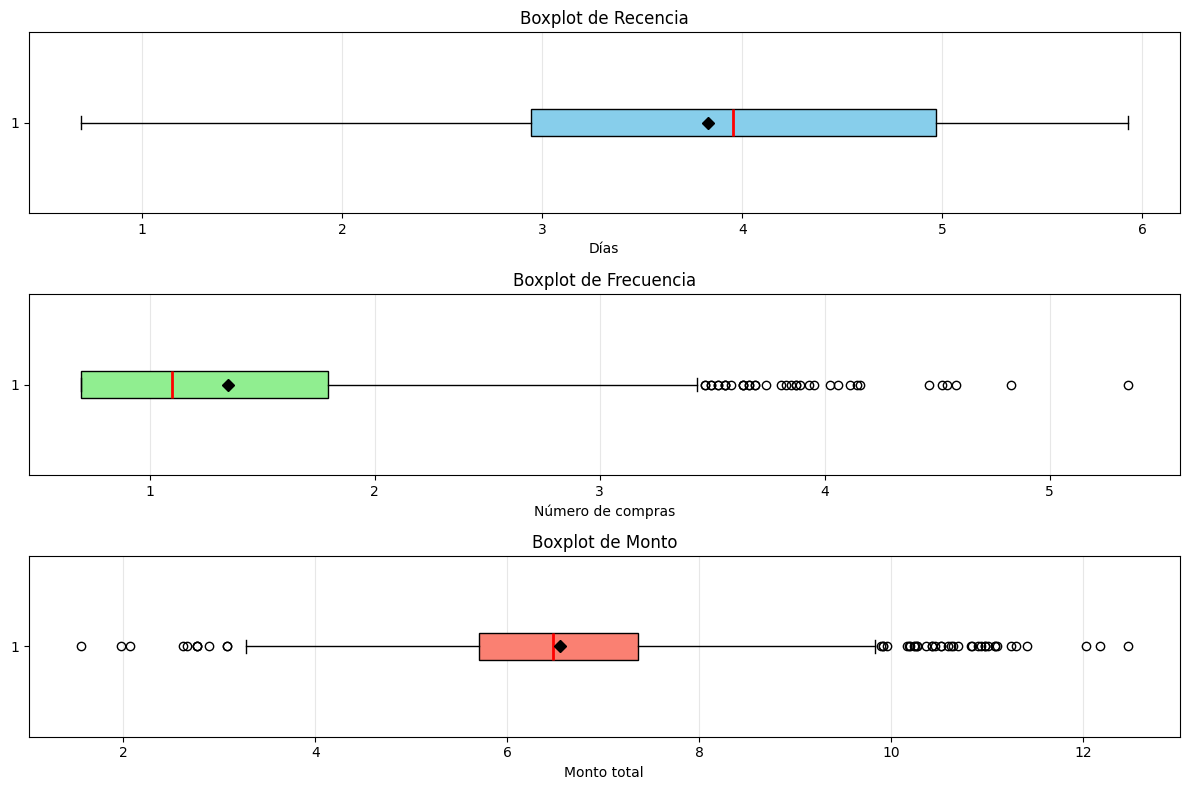

In [13]:
# Boxplots
# ----------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Recencia
axes[0].boxplot(
    rfm_log["recencia"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="skyblue"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[0].set_title("Boxplot de Recencia")
axes[0].set_xlabel("Días")
axes[0].grid(axis="x", alpha=0.3)

# Frecuencia
axes[1].boxplot(
    rfm_log["frecuencia"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="lightgreen"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[1].set_title("Boxplot de Frecuencia")
axes[1].set_xlabel("Número de compras")
axes[1].grid(axis="x", alpha=0.3)

# Monto
axes[2].boxplot(
    rfm_log["monto"],
    vert=False,
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor="salmon"),
    medianprops=dict(color="red", linewidth=2),
    meanprops=dict(marker="D", markerfacecolor="black", markeredgecolor="black")
)
axes[2].set_title("Boxplot de Monto")
axes[2].set_xlabel("Monto total")
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

Los boxplots muestran que la transformación logarítmica redujo significativamente la dispersión de las variables y comprimió los valores extremos. La recencia deja de presentar valores atípicos, mientras que en frecuencia y monto aún permanecen algunos outliers, aunque mucho menos alejados del resto de los datos. Esto indica que la transformación logró disminuir la influencia de los valores extremos sin eliminarlos, preservando la variabilidad natural de los clientes y haciendo las variables más adecuadas para algoritmos basados en distancias.

In [14]:
# Normalización
# ----------------------------

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = pd.DataFrame(
    scaler.fit_transform(rfm_log[["recencia", "frecuencia", "monto"]]),
    columns=["recencia", "frecuencia", "monto"],
    index=rfm.index
)

rfm_scaled.head()


,recencia,frecuencia,monto
0,1.463769,-0.957491,3.785914
1,-2.035554,1.668959,1.444280
2,-2.337994,5.864515,3.119983
3,-1.654524,0.652910,1.423880
4,-1.820969,0.385654,0.243880


In [15]:
# Fijar random state
# ----------------------------

np.random.seed(42)

# Etapa 2: Análisis exploratorio con clustering jerárquico

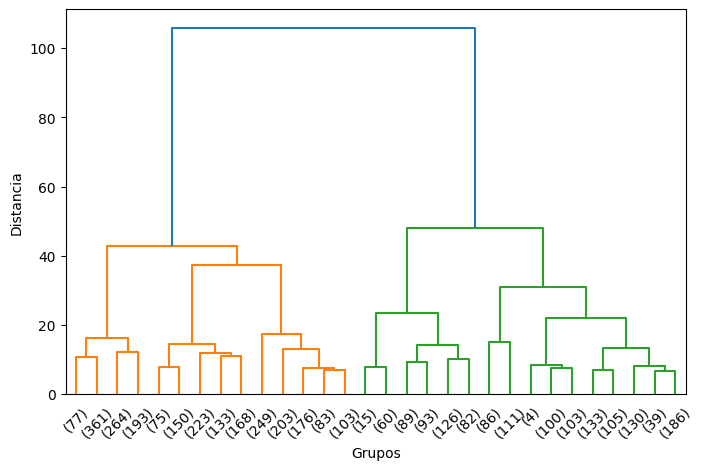

In [16]:
# Matriz de distancias (Ward)
# ----------------------------

# Importar linkage
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Crear matriz con metodo euclidiano
z_ward = linkage(rfm_scaled, method='ward', metric='euclidean')

# Dendograma
plt.figure(figsize=(8, 5))
dendrogram(z_ward, truncate_mode='lastp', p=30)
plt.xlabel("Grupos")
plt.ylabel("Distancia")
plt.show()

### Análisis de estructura jerárquica

Este dendrograma obtenido mediante el método Ward sugiere una estructura principal de dos clústeres, debido al salto pronunciado observado entre las últimas fusiones. Sin embargo, también se aprecia la existencia de subgrupos dentro de cada rama.

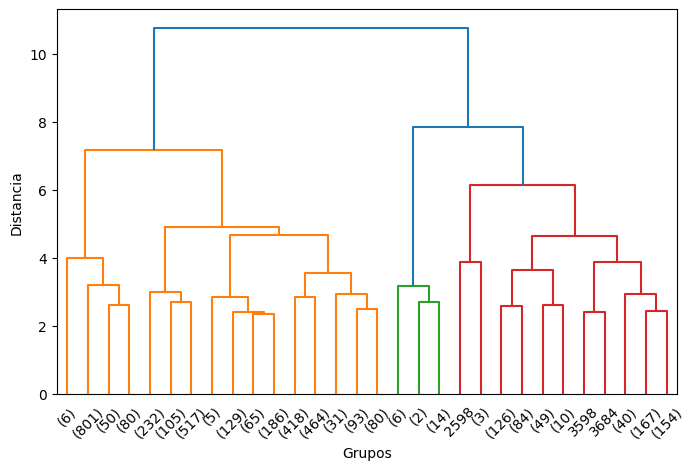

In [17]:
# Matriz de distancias (Complete)
# ----------------------------

# Crear matriz con metodo euclidiano
z_complete = linkage(rfm_scaled, method='complete', metric='euclidean')

# Dendograma
plt.figure(figsize=(8, 5))
dendrogram(z_complete, truncate_mode='lastp', p=30)
plt.xlabel("Grupos")
plt.ylabel("Distancia")
plt.show()

### Análisis de estructura jerárquica

El dendrograma obtenido mediante el método Complete sugiere una partición cercana a tres clústeres, ya que antes de la fusión final se distinguen tres ramas principales relativamente compactas. En comparación con el método Ward, Complete genera grupos más homogéneos internamente al considerar la distancia máxima entre observaciones

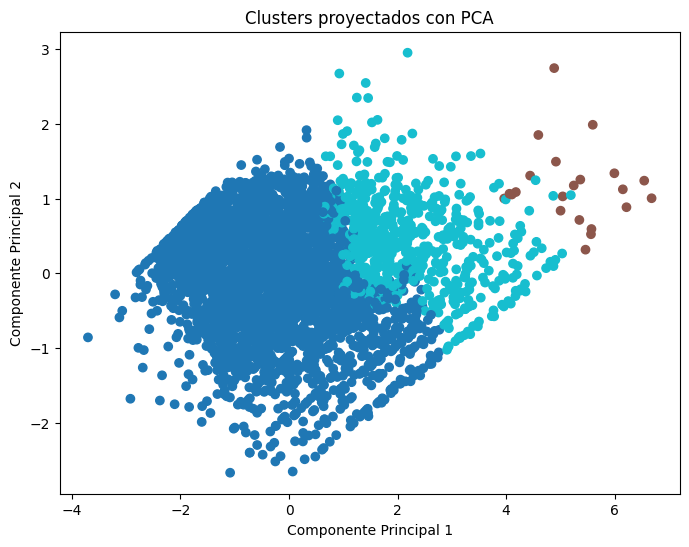

In [37]:
# Cortar el dendograma. Se utilizará el método "complete"
# ----------------------------

from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Corte
clusters = fcluster(z_complete, t=3, criterion='maxclust')

# PCA
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

# Scatter
plt.figure(figsize=(8,6))

plt.scatter(
    rfm_pca[:,0],
    rfm_pca[:,1],
    c=clusters,
    cmap="tab10"
)

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters proyectados con PCA")

plt.show()

In [36]:
# Conteo de clientes por cluster
# ----------------------------

conteo = pd.Series(clusters).value_counts().sort_index()
tabla = pd.DataFrame({
    "Cluster": conteo.index,
    "Número de clientes": conteo.values
})

tabla

,Cluster,Número de clientes
0,1,2458
1,2,1462


# Etapa 3: Segmentación con K-Medias

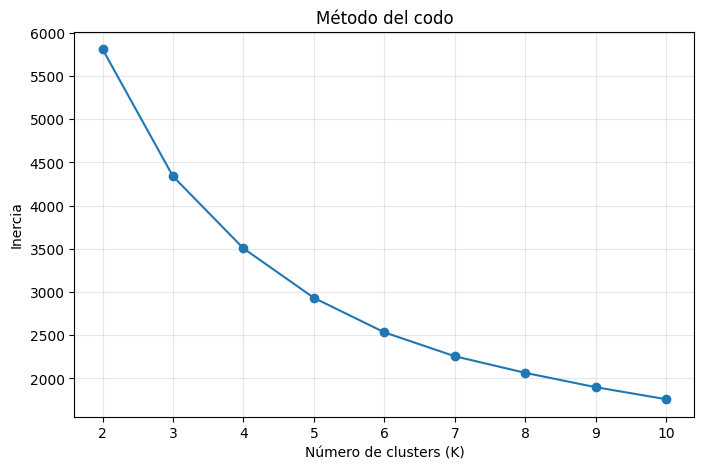

In [32]:
# Método del codo
# ----------------------------

from sklearn.cluster import KMeans

inercias = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)
    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Inercia")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()



Se observa que la inercia disminuye rápidamente al pasar de K = 2 a K = 5. A partir de ese punto, la reducción es mucho más gradual, por lo que agregar más clústeres aporta una mejora cada vez menor.

El "codo" de la curva se aprecia aproximadamente en K = 5, indicando que ese número de grupos ofrece un buen equilibrio entre simplicidad del modelo y reducción de la variabilidad dentro de los clústeres.

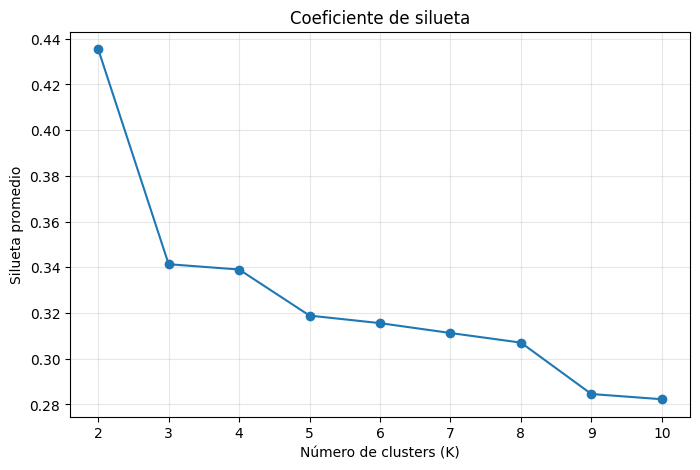

In [33]:
# Coeficiente de silueta
# ----------------------------

from sklearn.metrics import silhouette_score

siluetas = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = kmeans.fit_predict(rfm_scaled)

    siluetas.append(
        silhouette_score(rfm_scaled, etiquetas)
    )

plt.figure(figsize=(8,5))
plt.plot(K, siluetas, marker="o")
plt.title("Coeficiente de silueta")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silueta promedio")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

l coeficiente de silueta sugiere seleccionar K = 2, ya que es el valor que maximiza la calidad de la partición de acuerdo con esta métrica. Sin embargo, una segmentación en únicamente dos grupos puede resultar demasiado general para el análisis de clientes. Por ello, este criterio se complementará con el método del codo y con la utilidad práctica de los segmentos antes de seleccionar el valor final de K.

##### Declaración de selección de número de Clústeres

Los métodos jerárquicos y el coeficiente de silueta favorecen una partición con un número reducido de segmentos (2–3), lo que maximiza la separación entre grupos. Sin embargo, desde la perspectiva del negocio, una segmentación de únicamente dos o tres grupos resulta demasiado general para diferenciar perfiles de clientes con comportamientos distintos. Por su parte, el método del codo identifica un cambio de pendiente alrededor de K = 5, indicando que este valor ofrece un buen compromiso entre la reducción de la inercia y la complejidad del modelo. Por ello, se seleccionó K = 5, privilegiando una segmentación más útil e interpretable para la toma de decisiones comerciales, aun cuando otros criterios sugieren un menor número de clústeres.

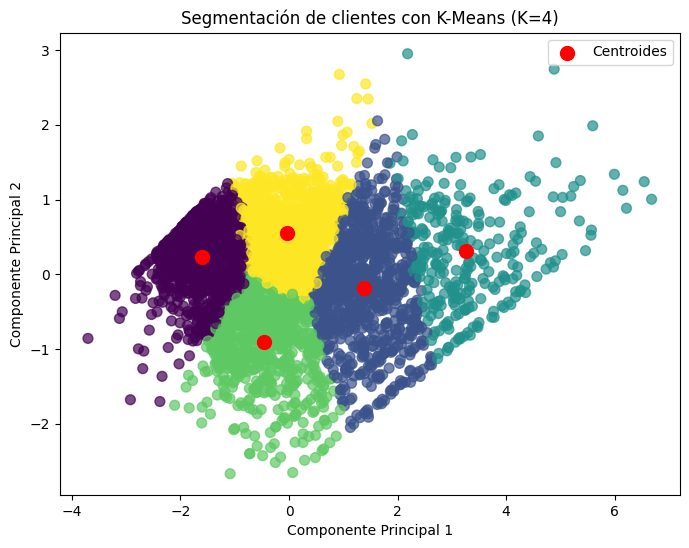

In [38]:
# K-Medias
# ----------------------------

# Inicializar modelos
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=42, n_init=10)
kmeans.fit(rfm_scaled)

# Entrenar y obtener asignaciones
y_kmeans = kmeans.fit_predict(rfm_scaled)

# Centroides en el espacio original escalado
centroids = kmeans.cluster_centers_

# PCA para visualización 2D
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

# Proyectar también los centroides al espacio PCA
centroids_pca = pca.transform(centroids)

# Graficar los resultados
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm_pca[:, 0],
    rfm_pca[:, 1],
    c=y_kmeans,
    s=50,
    cmap="viridis",
    alpha=0.7
)

# Centroides
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c="red",
    s=100,
    marker="o",
    label="Centroides"
)

plt.title("Segmentación de clientes con K-Means (K=4)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.show()


In [39]:
# Caracterización de segmentos
# ----------------------------

# Agregar el cluster al RFM original
rfm["cluster2"] = y_kmeans

segmentos = (
    rfm.groupby("cluster2")[["recencia", "frecuencia", "monto"]]
       .mean()
       .round(2)
)

segmentos

,recencia,frecuencia,monto
cluster2,,,
0,206.57,1.21,269.51
1,19.02,5.93,2120.19
2,11.32,20.93,12558.09
3,26.90,1.65,381.12
4,102.86,3.18,1378.34


In [40]:
# Número y porcentaje de clientes por segmento
# ----------------------------

tam_segmentos = (
    rfm.groupby("cluster2")
       .size()
       .reset_index(name="Clientes")
)

tam_segmentos["Porcentaje"] = (
    100 * tam_segmentos["Clientes"] / len(rfm)
).round(2)

tam_segmentos

,cluster2,Clientes,Porcentaje
0,0,1106,28.21
1,1,859,21.91
2,2,291,7.42
3,3,761,19.41
4,4,903,23.04


Ninguno de los Clústeres obtenidos tienen menos de 3% del total de clientes, por lo que se continuará con k = 5.

### Asignación de etiquetas (K = 5)

| Clúster | Etiqueta | Justificación |
|---------:|-----------|---------------|
| **0** | **Clientes dormidos** | Presentan la mayor recencia, muy baja frecuencia de compra y el menor monto promedio, por lo que representan clientes que llevan mucho tiempo sin comprar. |
| **1** | **Clientes activos** | Compran de forma relativamente reciente, con una frecuencia y gasto intermedios. Constituyen clientes recurrentes con actividad constante. |
| **2** | **Clientes VIP** | Son los clientes más valiosos: compran muy recientemente, realizan muchas compras y generan el mayor monto promedio. |
| **3** | **Clientes nuevos** | Han comprado recientemente, pero todavía presentan baja frecuencia y bajo monto acumulado, lo que indica que aún están iniciando su relación con la empresa. |
| **4** | **Clientes en riesgo** | Aunque anteriormente realizaron varias compras y acumulan un gasto medio, hace tiempo que no compran, por lo que existe riesgo de abandono. |

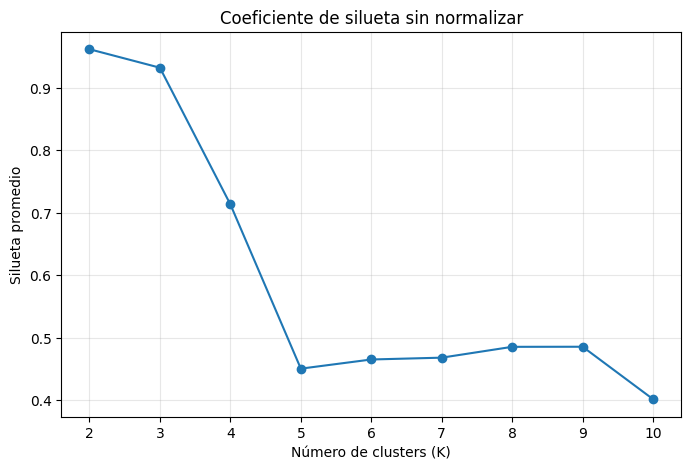

In [41]:
# Coeficiente de silueta sin normalizar
# ----------------------------

siluetas = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    etiquetas = kmeans.fit_predict(rfm)

    siluetas.append(
        silhouette_score(rfm, etiquetas)
    )

plt.figure(figsize=(8,5))
plt.plot(K, siluetas, marker="o")
plt.title("Coeficiente de silueta sin normalizar")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silueta promedio")
plt.xticks(K)
plt.grid(alpha=0.3)
plt.show()

### Discusión sobre la métrica de silueta

La selección de K sin transformación logarítmica produce coeficientes de silueta superiores, particularmente para K = 2 y K = 3. Sin embargo, estos valores elevados se deben en gran medida a la fuerte asimetría y presencia de valores extremos en las variables Frecuencia y Monto. Los clientes con valores excepcionalmente altos quedan muy separados del resto, lo que incrementa la distancia entre clústeres y, por tanto, el coeficiente de silueta.

Al aplicar la transformación logarítmica, se reduce la influencia de estos valores extremos y las distancias entre clientes representan de manera más equilibrada sus diferencias de comportamiento. Aunque los valores de silueta son menores, se prefiere la versión transformada porque produce una segmentación menos dominada por outliers y más útil para caracterizar perfiles de clientes.

In [42]:
from sklearn.metrics import adjusted_rand_score

# Tabla de contingencia
tabla_contingencia = pd.crosstab(
    clusters,
    y_kmeans,
    rownames=["Jerárquico"],
    colnames=["K-Means"]
)

print(tabla_contingencia)

# Índice de Rand ajustado
ari = adjusted_rand_score(clusters, y_kmeans)

print(f"\nAdjusted Rand Index: {ari:.3f}")

K-Means        0    1    2    3    4
Jerárquico                          
1           1106  543    8  761  844
2              0    0   22    0    0
3              0  316  261    0   59

Adjusted Rand Index: 0.106


La comparación entre ambos métodos muestra un bajo nivel de acuerdo (ARI = 0.106). El método jerárquico "Complete" y tres clústeres produce una segmentación mucho más general, mientras que K-Means con cinco clústeres identifica una estructura más detallada, dividiendo los clientes en segmentos adicionales. La tabla de contingencia evidencia que los grupos del clustering jerárquico contienen clientes pertenecientes a varios segmentos de K-Means, por lo que no existe una correspondencia clara entre ambos resultados. Esta diferencia es consistente con el hecho de que ambos algoritmos utilizan criterios de agrupamiento distintos y, además, se comparan particiones con diferente número de clústeres (3 vs. 5).

# Etapa 4: Clasificación de nuevos clientes con K-NN

In [43]:
# Variables predictoras
X = rfm_scaled

# Variable objetivo (segmento asignado por K-Means)
y = y_kmeans

In [44]:
# División del dataset
# ----------------------------

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [45]:
# Entrenar modelo K-NN
# ----------------------------

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

vecinos = [1, 3, 5, 7, 9, 11]

resultados = []

for k in vecinos:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    
    resultados.append([k, acc])

resultados = pd.DataFrame(resultados, columns=["Vecinos (K)", "Accuracy"])

resultados

,Vecinos (K),Accuracy
0,1,0.980867
1,3,0.971939
2,5,0.974490
3,7,0.978316
4,9,0.970663
5,11,0.970663


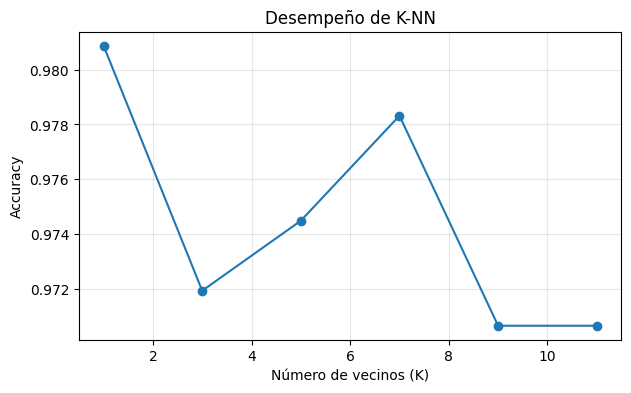

In [46]:
# Grafica de accuracy
# ----------------------------

plt.figure(figsize=(7,4))
plt.plot(resultados["Vecinos (K)"], resultados["Accuracy"], marker="o")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy")
plt.title("Desempeño de K-NN")
plt.grid(alpha=0.3)
plt.show()

In [47]:
# Validación cruzada
# ----------------------------

from sklearn.model_selection import StratifiedKFold

# Validación cruzada estratificada de 5 folds
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados = []

for k in vecinos:

    accuracies = []

    for train_index, val_index in skf.split(X_train, y_train):

        X_tr = X_train.iloc[train_index]
        X_val = X_train.iloc[val_index]

        y_tr = y_train[train_index]
        y_val = y_train[val_index]

        knn = KNeighborsClassifier(n_neighbors=k)

        knn.fit(X_tr, y_tr)

        y_pred = knn.predict(X_val)

        accuracies.append(
            accuracy_score(y_val, y_pred)
        )

    resultados.append({
        "Vecinos (K)": k,
        "Accuracy promedio": np.mean(accuracies),
        "Desv. estándar": np.std(accuracies)
    })

resultados_cv = pd.DataFrame(resultados)

resultados_cv


,Vecinos (K),Accuracy promedio,Desv. estándar
0,1,0.962690,0.007924
1,3,0.964284,0.011263
2,5,0.964605,0.004771
3,7,0.966837,0.008700
4,9,0.966199,0.011386
5,11,0.962375,0.008461


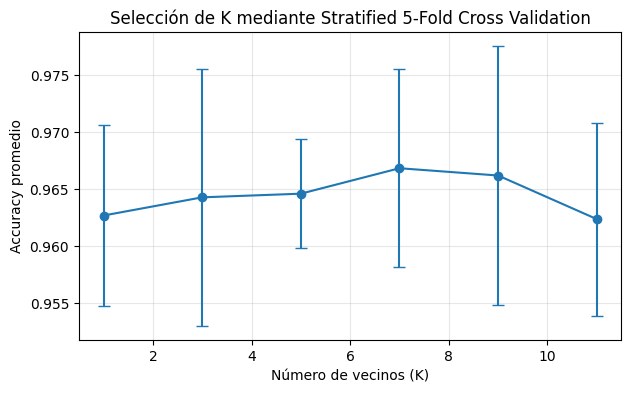

In [48]:
plt.figure(figsize=(7,4))

plt.errorbar(
    resultados_cv["Vecinos (K)"],
    resultados_cv["Accuracy promedio"],
    yerr=resultados_cv["Desv. estándar"],
    fmt='o-',
    capsize=4
)

plt.xlabel("Número de vecinos (K)")
plt.ylabel("Accuracy promedio")
plt.title("Selección de K mediante Stratified 5-Fold Cross Validation")
plt.grid(alpha=0.3)

plt.show()

Se evaluaron distintos valores del número de vecinos mediante validación cruzada estratificada de 5 folds. El mejor desempeño se obtuvo con K = 7, alcanzando un accuracy promedio de 96.68 %. Aunque K = 5 presentó una desviación estándar ligeramente menor, la diferencia en estabilidad fue pequeña y K = 7 obtuvo la mayor precisión promedio. Por este motivo, se seleccionó K = 7 como el número óptimo de vecinos para el modelo K-NN.

In [49]:
# Evaluación de ponderación por distancia
# ----------------------------

pesos = ["uniform", "distance"]

resultados = []

for peso in pesos:

    knn = KNeighborsClassifier(
        n_neighbors=7,
        weights=peso
    )

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    resultados.append({
        "Weights": peso,
        "Accuracy": accuracy_score(y_test, y_pred)
    })

resultados = pd.DataFrame(resultados)

resultados

,Weights,Accuracy
0,uniform,0.978316
1,distance,0.985969


Se evaluó el efecto de la ponderación de los vecinos utilizando weights="uniform" y weights="distance" con K = 7. La ponderación por distancia obtuvo un accuracy de 98.60 %, superior al 97.83 % obtenido con ponderación uniforme. Esto indica que considerar una mayor influencia de los vecinos más cercanos mejora la capacidad del modelo para asignar correctamente nuevos clientes a los segmentos definidos por K-Means. Por esta razón, el modelo final se implementó utilizando K = 7 y weights="distance".

Accuracy: 0.9860

Reporte de clasificación:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       221
           1       0.98      0.99      0.99       172
           2       1.00      0.98      0.99        58
           3       0.99      0.98      0.98       152
           4       0.99      0.97      0.98       181

    accuracy                           0.99       784
   macro avg       0.99      0.99      0.99       784
weighted avg       0.99      0.99      0.99       784



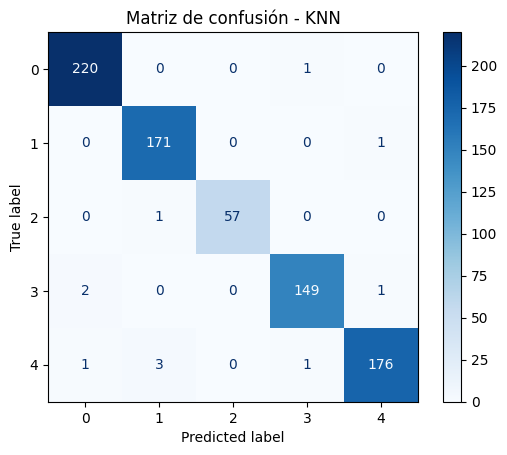

In [52]:
# Evaluación del modelo
# ----------------------------

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

# Modelo final
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)

knn.fit(X_train, y_train)

# Predicciones
y_pred = knn.predict(X_test)

# Accuracy
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# Precision, Recall y F1-score
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Matriz de confusión - KNN")
plt.show()

El modelo K-NN con K = 7 y ponderación por distancia obtuvo un Accuracy de 98.60 %, demostrando una excelente capacidad para reproducir la segmentación generada por K-Means. Las métricas de Precision, Recall y F1-score fueron superiores a 0.97 en todos los segmentos, mientras que la matriz de confusión evidencia que los errores de clasificación son escasos y se concentran entre segmentos con perfiles cercanos. En conjunto, los resultados indican que el modelo constituye una herramienta confiable para asignar nuevos clientes a los segmentos definidos previamente sin necesidad de ejecutar nuevamente el algoritmo de clustering.

In [55]:
# Demostración de predicciones
# ----------------------------

# 3 clientes nuevos simulados en escala ORIGINAL
nuevos_clientes = pd.DataFrame({
    "recencia": [220, 15, 8],
    "frecuencia": [1, 8, 25],
    "monto": [300, 2500, 15000]})

nuevos_clientes

,recencia,frecuencia,monto
0,220,1,300
1,15,8,2500
2,8,25,15000


In [56]:
# Transformación
nuevos_log = nuevos_clientes.copy()

nuevos_log["recencia"] = np.log1p(nuevos_log["recencia"])
nuevos_log["frecuencia"] = np.log1p(nuevos_log["frecuencia"])
nuevos_log["monto"] = np.log1p(nuevos_log["monto"])

# Normalización
nuevos_scaled = scaler.transform(
    nuevos_log[["recencia", "frecuencia", "monto"]]
)

predicciones = knn.predict(nuevos_scaled)

nuevos_clientes["cluster_predicho"] = predicciones

etiquetas = {
    0: "Clientes dormidos",
    1: "Clientes activos",
    2: "Clientes VIP",
    3: "Clientes nuevos",
    4: "Clientes en riesgo"
}

nuevos_clientes["segmento"] = nuevos_clientes["cluster_predicho"].map(etiquetas)

nuevos_clientes

,recencia,frecuencia,monto,cluster_predicho,segmento
0,220,1,300,0,Clientes dormidos
1,15,8,2500,1,Clientes activos
2,8,25,15000,2,Clientes VIP


Para demostrar el funcionamiento del clasificador, se generaron tres clientes con diferentes perfiles RFM. Antes de realizar la predicción, cada cliente recorrió exactamente la misma cadena de preprocesamiento utilizada durante el entrenamiento del modelo: primero se aplicó la transformación logarítmica log1p y posteriormente la estandarización mediante el StandardScaler previamente ajustado, utilizando el método transform(). Finalmente, el modelo K-NN asignó a cada cliente uno de los cinco segmentos definidos por K-Means. Los resultados obtenidos son consistentes con las características de cada perfil, clasificando como clientes dormidos a aquellos con alta recencia y bajo nivel de actividad, como clientes activos a quienes presentan compras recientes y comportamiento recurrente, y como clientes VIP a los clientes con alta frecuencia y elevado monto de compra.

In [ ]:
# ----------------------------